A Mundial Eletrônica nos procurou enfrentando um sério risco de segurança: seus funcionários, sobrecarregados com o volume de e-mails, estavam caindo em golpes de phishing.

Para resolver isso, desenvolvemos um código em Python com Inteligência Artificial. Essa solução agora funciona como uma barreira de proteção, analisando automaticamente as mensagens e alertando sobre tentativas de fraude antes que alguém clique em um link malicioso.

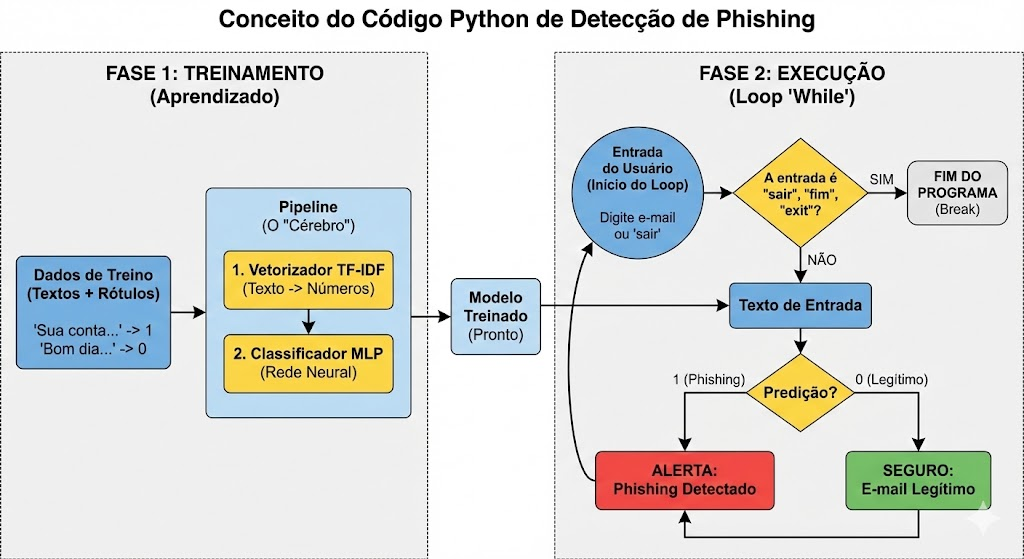

In [2]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline


In [6]:
dados_treino = [
    "Sua conta foi bloqueada, clique aqui para recadastrar sua senha urgente",
    "Parabéns você ganhou um sorteio, envie seus dados bancários agora",
    "Segue em anexo o relatório mensal de vendas da equipe",
    "Vamos marcar uma reunião para discutir o projeto amanhã?",
    "Urgente: atualize seus dados cadastrais para evitar suspensão",
    "O almoço de confraternização será no restaurante da esquina",
    "Clique neste link para baixar sua fatura atrasada",
    "Bom dia, poderia me enviar a apresentação atualizada?",
    "Seu cartão foi clonado, verifique sua identidade aqui",
    "Promoção imperdível: iPhone por R$ 100,00, compre já",
    "A ata da reunião passada está disponível no drive",
    "Por favor, confirme sua presença na festa de fim de ano",
    "Notificação judicial: compareça para audiência online",
    "Oi, segue a foto do nosso final de semana"
]

labels = [1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]

print("⚙️  Inicializando a Rede Neural...")

modelo = make_pipeline(
    TfidfVectorizer(),
    MLPClassifier(hidden_layer_sizes=(12,), max_iter=2000, random_state=42)
)

print("🧠 Treinando o modelo com os exemplos...")
modelo.fit(dados_treino, labels)
print("✅ Modelo treinado e pronto para uso!\n")


print("="*60)
print("   🕵️  DETECTOR DE PHISHING ATIVO")
print("   Digite o texto do e-mail para analisar.")
print("   Digite 'sair', 'fim' ou 'exit' para encerrar o programa.")
print("="*60)

while True:

    texto_usuario = input("\n📝 Digite o texto do e-mail: ")


    if texto_usuario.lower() in ['sair', 'fim', 'exit']:
        print("\n🛑 Encerrando o sistema... Até a próxima!")
        break

    if not texto_usuario.strip():
        continue


    predicao = modelo.predict([texto_usuario])[0]
    probabilidade = modelo.predict_proba([texto_usuario])[0]

    print("-" * 60)
    if predicao == 1:
        confianca = probabilidade[1] * 100
        print(f"🚨 RESULTADO: PHISHING DETECTADO!")
        print(f"📊 Confiança da IA: {confianca:.2f}%")
        print("🛡️  Recomendação: Cuidado! Possível Engenharia Social.")
    else:
        confianca = probabilidade[0] * 100
        print(f"✅ RESULTADO: E-mail Legítimo.")
        print(f"📊 Confiança da IA: {confianca:.2f}%")
        print("👍 Recomendação: Parece seguro.")
    print("-" * 60)

⚙️  Inicializando a Rede Neural...
🧠 Treinando o modelo com os exemplos...
✅ Modelo treinado e pronto para uso!

   🕵️  DETECTOR DE PHISHING ATIVO
   Digite o texto do e-mail para analisar.
   Digite 'sair', 'fim' ou 'exit' para encerrar o programa.

📝 Digite o texto do e-mail: AMAZON PRIME  Olá Cliente,  Seu pagamento foi recusado no último ciclo de renovação. Para evitar o cancelamento dos seus pedidos pendentes e a perda do frete grátis, atualize seu cartão padrão imediatamente.  MANTER MEUS BENEFÍCIOS  Caso já tenha efetuado o pagamento, desconsidere este e-mail. Acesse sua conta para mais detalhes.
------------------------------------------------------------
🚨 RESULTADO: PHISHING DETECTADO!
📊 Confiança da IA: 98.19%
🛡️  Recomendação: Cuidado! Possível Engenharia Social.
------------------------------------------------------------

📝 Digite o texto do e-mail: NETFLLIX  Oi  Estamos tendo problemas com suas informações de faturamento atuais. Tentaremos novamente, mas por enquanto voc